In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MaxNLocator

In [2]:
def nonlin_func(x):
    x0,x1=x[0],x[1]
    return np.array([
        (x0**2)-(2*x0)-(2*x1**2)+x1,
        (x0**2)+(x0)-(2*x1**2)-(1.5*x1)-(0.05)
    ])

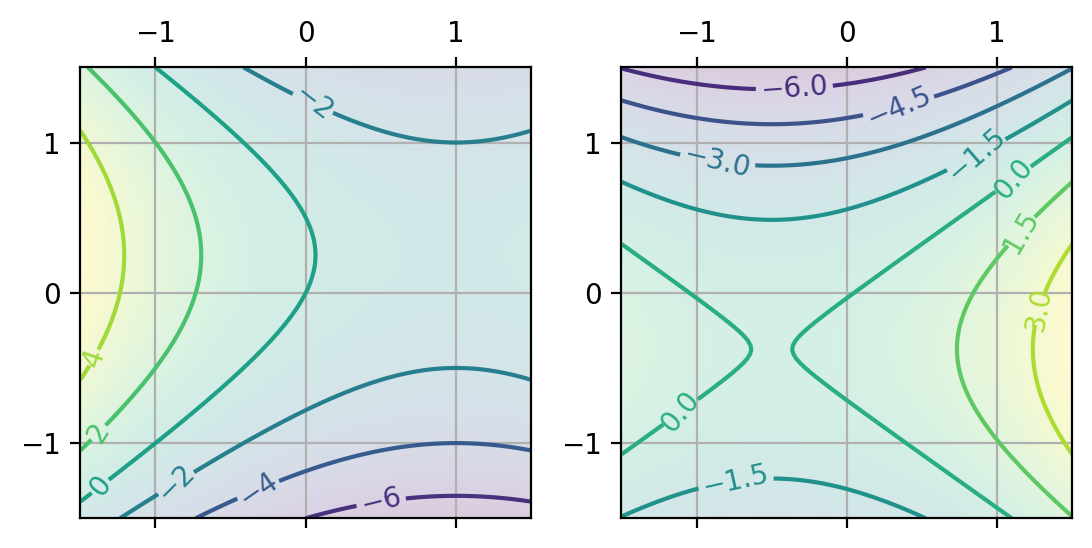

In [3]:
#graphing nonlin_func 
x=np.linspace(-1.5,1.5,100)
y=np.linspace(-1.5,1.5,100)
X,Y=np.meshgrid(x,y)
output=nonlin_func(np.array([X,Y]))

fig,axs=plt.subplots(1,2,dpi=200)

my_extent=[min(x),max(x),min(y),max(y)]
axs[0].matshow(output[0],origin="lower",extent=my_extent,alpha=0.2)
csx=axs[0].contour(X,Y,output[0])
axs[0].clabel(csx)

axs[1].matshow(output[1],origin="lower",extent=my_extent,alpha=0.2)
csy=axs[1].contour(X,Y,output[1])
axs[1].clabel(csy)

for ax in axs:
    ax.grid(True)

In [4]:
def jacobian(vec_fld,x,h=1e-6):
    n=x.size
    Jf=np.zeros((n,n))
    iden=np.eye(n)
    fs0=vec_fld(x)
    for j in range(n):
        fs1=vec_fld(x+iden[:,j]*h)
        Jf[:,j]=(fs1-fs0)/h
 
    return Jf,fs0

In [5]:
def termcrit(xolds,xnews):
    errs = np.abs((xnews - xolds)/xnews)
    return np.sum(errs)

In [6]:
def multi_newton(input_func, jac, xolds, kmax=500,tol=1.e-8):
    
    for k in range(1, kmax):
        Jf, fs_xolds = jacobian(input_func, xolds)
        xnews = xolds + np.linalg.solve(Jf, -fs_xolds)

        err=termcrit(xolds,xnews)
        print(k,xnews,err)
        if err<tol:
            break

        xolds = np.copy(xnews)
    else:
        xnews=None
    return xnews

root = multi_newton(nonlin_func, jacobian, np.array([1., 1.]))
print(f"Root found at {root}")
print(f"f(root) is {nonlin_func(root)})")

1 [0.29444462 0.33333354] 4.396222522995076
2 [0.07851081 0.07421297] 6.2419508690183
3 [-0.00921903 -0.03106283] 12.905297282276624
4 [-0.03083679 -0.05700415] 1.156115812757831
5 [-0.03233088 -0.05879705] 0.07670556899861904
6 [-0.03233809 -0.0588057 ] 0.0003700365336538104
7 [-0.03233809 -0.0588057 ] 9.500454999808983e-09
Root found at [-0.03233809 -0.0588057 ]
f(root) is [-2.56739074e-16 -2.56739074e-16])


1 [-0.44999984 -0.5599998 ] 2.007937953986756
2 [-0.36427108 -0.4571253 ] 0.4603899202496541
3 [-0.34351449 -0.43221739] 0.11805241239353219
4 [-0.34213613 -0.43056335] 0.007870246598537493
5 [-0.34213  -0.430556] 3.499757634096684e-05
6 [-0.34213  -0.430556] 6.082942781202117e-10
Root found at [-0.34213  -0.430556] => L2 = 1.8875832159447664e-16
1 [0.13947406 0.14736887] 13.95548568418376
2 [ 0.0128391  -0.00459308] 42.94822248107515
3 [-0.02723743 -0.05268492] 2.3841970072353513
4 [-0.03225677 -0.05870813] 0.2582015801163511
5 [-0.03233807 -0.05880568] 0.004172781306454784
6 [-0.03233809 -0.0588057 ] 1.105027158308932e-06
7 [-0.03233809 -0.0588057 ] 2.7324871836876164e-12
Root found at [-0.03233809 -0.0588057 ] => L2 = 9.813077866773595e-18
1 [-0.14999954 -0.19999945] 11.666700779395047
2 [0.15356466 0.16427759] 4.1942324585787025
3 [0.01836623 0.00203948] 86.91017219592577
4 [-0.02608576 -0.05130291] 2.743824748380488
5 [-0.03221678 -0.05866014] 0.3157265282184586
6 [-0.03233804 -0.

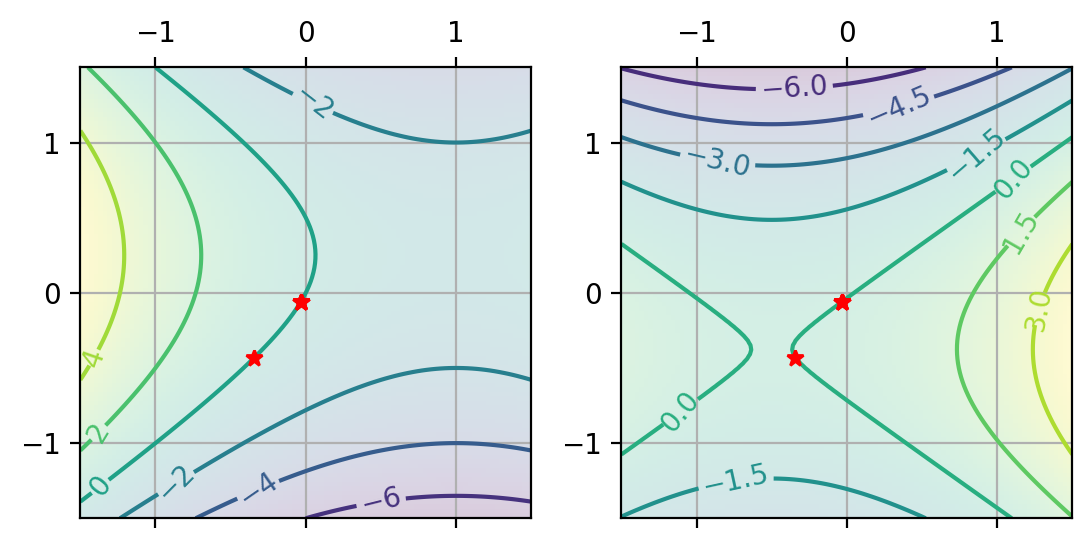

In [7]:
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
output = nonlin_func(np.array([X, Y]))

fig, axs = plt.subplots(1, 2, dpi=200)
my_extent = [min(x), max(x), min(y), max(y)]
axs[0].matshow(output[0], origin="lower", extent=my_extent, alpha=0.2)
csx = axs[0].contour(X, Y, output[0])
axs[0].clabel(csx)

axs[1].matshow(output[1], origin="lower", extent=my_extent, alpha=0.2)
csy = axs[1].contour(X, Y, output[1])
axs[1].clabel(csy)

for ax in axs:
    ax.grid(True)
    ## Try out different x0 and see where they will land
    for x0 in [[-1, -1],[-1, 1], [1, -1], [0,0], [1,1]]:
        root = multi_newton(nonlin_func, jacobian, np.array(x0))
        print(f"Root found at {root} => L2 = {np.linalg.norm(nonlin_func(root))}")
        ax.plot(root[0], root[1], "r*")